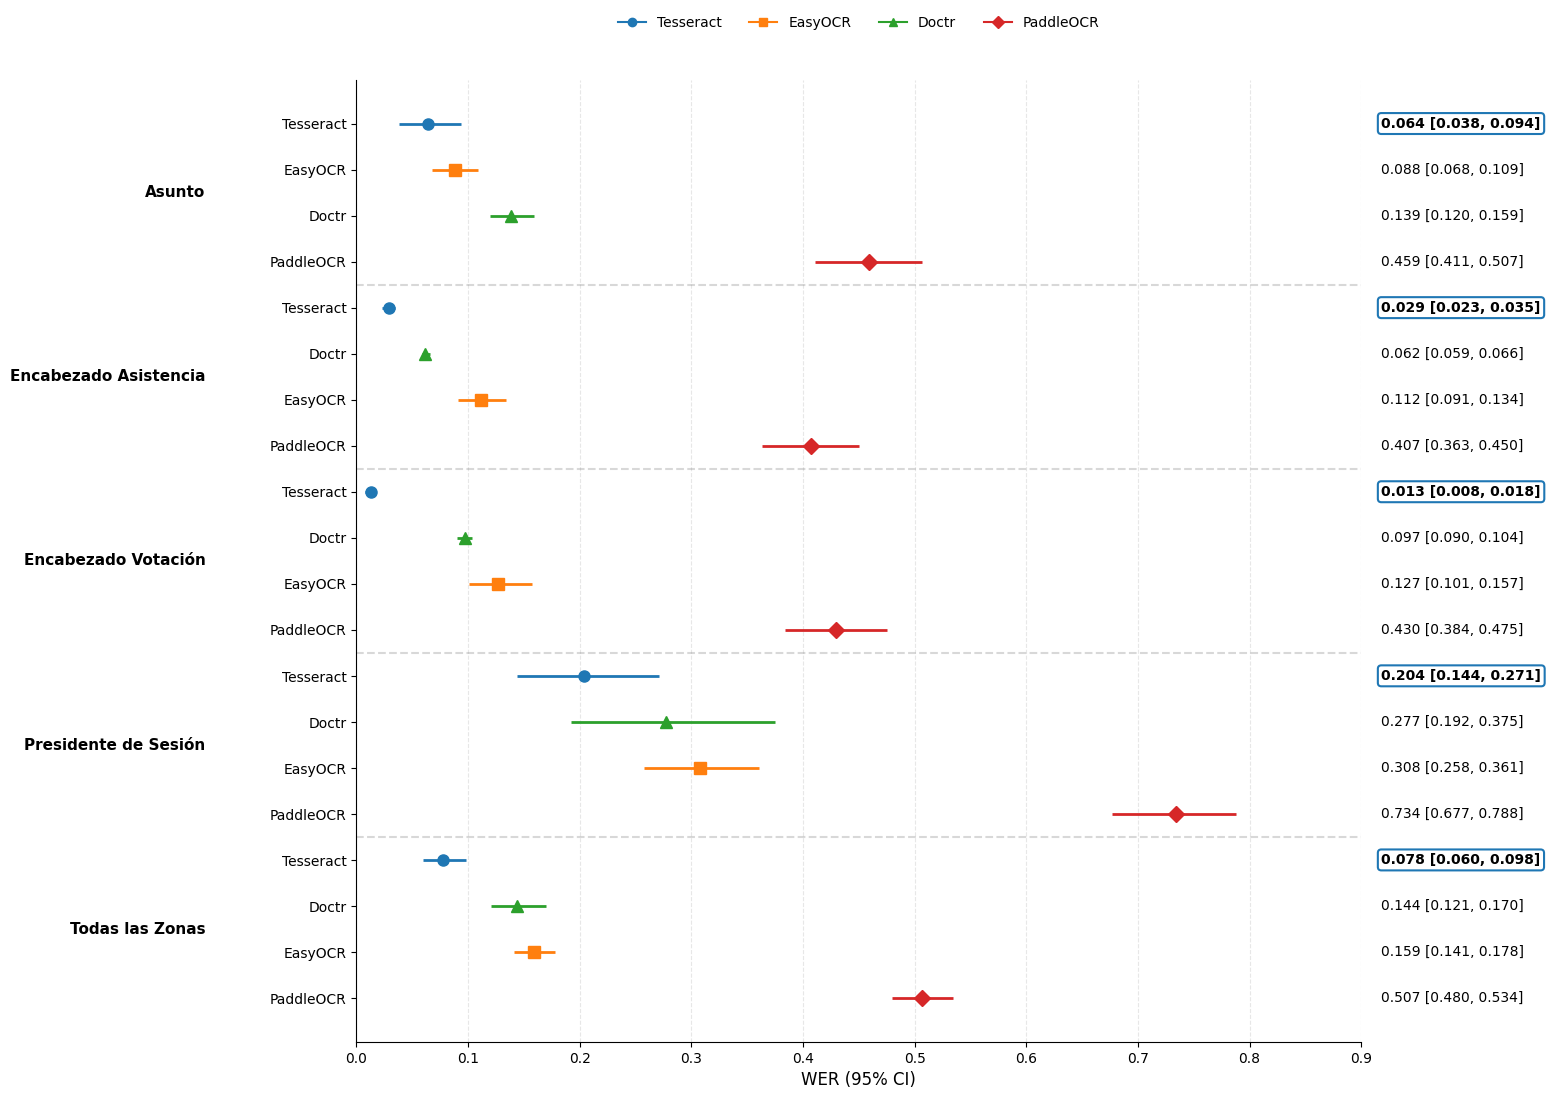

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# =========================
# DATOS SOLO WER
# =========================
rows = [
    ("Tesseract", "Asunto", 0.064, 0.038, 0.094),
    ("Tesseract", "Encabezado Asistencia", 0.029, 0.023, 0.035),
    ("Tesseract", "Encabezado Votación", 0.013, 0.008, 0.018),
    ("Tesseract", "Presidente de Sesión", 0.204, 0.144, 0.271),
    ("Tesseract", "Todas las Zonas", 0.078, 0.060, 0.098),

    ("EasyOCR", "Asunto", 0.088, 0.068, 0.109),
    ("EasyOCR", "Encabezado Asistencia", 0.112, 0.091, 0.134),
    ("EasyOCR", "Encabezado Votación", 0.127, 0.101, 0.157),
    ("EasyOCR", "Presidente de Sesión", 0.308, 0.258, 0.361),
    ("EasyOCR", "Todas las Zonas", 0.159, 0.141, 0.178),

    ("Doctr", "Asunto", 0.139, 0.120, 0.159),
    ("Doctr", "Encabezado Asistencia", 0.062, 0.059, 0.066),
    ("Doctr", "Encabezado Votación", 0.097, 0.090, 0.104),
    ("Doctr", "Presidente de Sesión", 0.277, 0.192, 0.375),
    ("Doctr", "Todas las Zonas", 0.144, 0.121, 0.170),

    ("PaddleOCR", "Asunto", 0.459, 0.411, 0.507),
    ("PaddleOCR", "Encabezado Asistencia", 0.407, 0.363, 0.450),
    ("PaddleOCR", "Encabezado Votación", 0.430, 0.384, 0.475),
    ("PaddleOCR", "Presidente de Sesión", 0.734, 0.677, 0.788),
    ("PaddleOCR", "Todas las Zonas", 0.507, 0.480, 0.534),
]

colors = {
    "Tesseract": "#1f77b4",
    "EasyOCR": "#ff7f0e",
    "Doctr": "#2ca02c",
    "PaddleOCR": "#d62728",
}

markers = {
    "Tesseract": "o",
    "EasyOCR": "s",
    "Doctr": "^",
    "PaddleOCR": "D",
}

# =========================
# AGRUPAR POR ZONA
# =========================
grouped = defaultdict(list)
for model, region, mean, low, high in rows:
    grouped[region].append((model, mean, low, high))

region_order = [
    "Asunto",
    "Encabezado Asistencia",
    "Encabezado Votación",
    "Presidente de Sesión",
    "Todas las Zonas",
]

plot_data = []
y_labels = []
best_indices = []
separators = []
region_positions = {}

idx = 0

for region in region_order:
    group = sorted(grouped[region], key=lambda x: x[1])  # menor WER mejor
    best_model = group[0][0]
    region_positions[region] = []

    for model, mean, low, high in group:
        plot_data.append((model, region, mean, low, high))
        y_labels.append(model)
        region_positions[region].append(idx)

        if model == best_model:
            best_indices.append(idx)

        idx += 1

    separators.append(idx - 0.5)

# =========================
# PLOT
# =========================
y = np.arange(len(plot_data))[::-1]
fig, ax = plt.subplots(figsize=(15, 11))

for i, (model, region, mean, low, high) in enumerate(plot_data):
    yy = y[i]

    ax.errorbar(
        mean,
        yy,
        xerr=[[mean - low], [high - mean]],
        fmt=markers[model],
        color=colors[model],
        markersize=8,
        linewidth=2,
    )

    ax.text(
        1.02,
        yy,
        f"{mean:.3f} [{low:.3f}, {high:.3f}]",
        transform=ax.get_yaxis_transform(),
        va="center",
        fontsize=10,
        fontweight="bold" if i in best_indices else "normal",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor=colors[model],
            linewidth=1.5,
        ) if i in best_indices else None,
    )

# Headers de zona
for region, indices in region_positions.items():
    y_pos = np.mean([y[i] for i in indices])

    ax.text(
        -0.15,
        y_pos,
        region,
        transform=ax.get_yaxis_transform(),
        ha="right",
        va="center",
        fontsize=11,
        fontweight="bold",
    )

# Separadores
for sep in separators[:-1]:
    ax.axhline(y=sep, color="gray", linestyle="--", alpha=0.3)

# =========================
# CONFIG
# =========================
ax.set_yticks(y)
ax.set_yticklabels(y_labels, fontsize=10)

ax.set_xlabel("WER (95% CI)", fontsize=12)
ax.set_xlim(0.0, 0.90)

ax.grid(axis="x", linestyle="--", alpha=0.3)

for model in colors:
    ax.plot([], [], marker=markers[model], color=colors[model], label=model)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=4,
    frameon=False,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.subplots_adjust(left=0.32, right=0.75)

plt.tight_layout()
plt.savefig("5_ocr_wer.png", dpi=300, bbox_inches="tight")
plt.show()